# Penalized Linear Regressions: A Simulation Experiment

In [1]:
import matplotlib.pyplot as plt
import random
import numpy as np
import warnings
warnings.simplefilter('ignore')
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV, ElasticNetCV, LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
import pandas as pd
from sklearn.base import BaseEstimator
random.seed(1)

## Data Generating Process

We define a simple data generating process that allows for sparse, dense, and sparse+dense coefficients

In [2]:
def gen_data(n, p, *, regime="sparse"):
    # constants chosen to get R^2 of approximately .80
    if regime == "sparse":
        beta = ((1 / np.arange(1, p + 1)) ** 2) * 7
    elif regime == "dense":
        beta = ((np.random.normal(0, 1, p)) * 0.35)
    elif regime == "sparsedense":
        # taking out either results in an R^2 of approximately .69
        beta = (((1 / np.arange(1, p + 1)) ** 2) * 5) + ((np.random.normal(0, 1, p)) * 0.25)

    def true_fn(x):
        return x @ beta

    X = np.random.uniform(-.5, .5, size=(n, p))
    gX = true_fn(X)
    y = gX + np.random.normal(0, 1, size=n)
    Xtest = np.random.uniform(-.5, .5, size=(n, p))
    gXtest = true_fn(Xtest)
    ytest = gXtest + np.random.normal(0, 1, size=n)
    Xpop = np.random.uniform(-.5, .5, size=(100000, p))  # almost population limit
    gXpop = true_fn(Xpop)
    ypop = gXpop + np.random.normal(0, 1, size=100000)  # almost population limit
    return X, y, gX, Xtest, ytest, gXtest, Xpop, ypop, gXpop, beta

## Data Generating Process: Approximately Sparse

In [3]:
n = 100
p = 400
X, y, gX, Xtest, ytest, gXtest, Xpop, ypop, gXpop, betas = gen_data(n, p, regime="sparse")

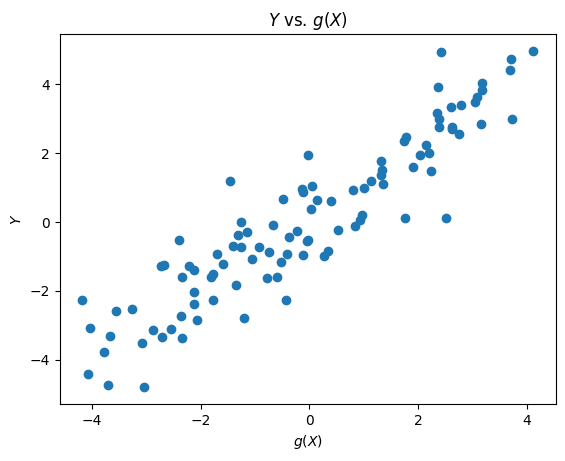

In [4]:
plt.figure()
plt.title(r"$Y$ vs. $g(X)$")
plt.scatter(gX, y)
plt.xlabel(r"$g(X)$")
plt.ylabel(r"$Y$")
plt.show()

In [5]:
print(f"theoretical R^2:, {1 - np.var(ypop - gXpop) / np.var(ypop)}")
print(f"theoretical R^2:, {np.var(gXpop) / np.var(ypop)}")

theoretical R^2:, 0.8148396490674255
theoretical R^2:, 0.8139142602750935


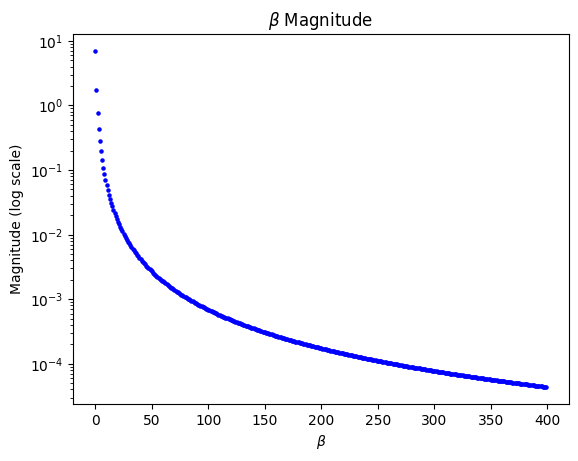

In [6]:
plt.figure()
plt.scatter(range(len(betas)), abs(betas), s=5, color='b')
plt.xlabel(r'$\beta$')
plt.ylabel('Magnitude (log scale)')
plt.title(r'$\beta$ Magnitude')
plt.yscale('log')
plt.show()

## Lasso, Ridge, ElasticNet

We use sklearn's penalized estimators, which choose the penalty parameter via cross-validation (by default 5-fold cross-validation). These methods search over an adaptively chosen grid of hyperparameters. `ElasticNet` allows for a convex combination of `l1` and `l2` penalty and the ratio with `l1_ratio` corresponding to the proportion of the `l1` penalty.

In [7]:
# Regressions
lcv = LassoCV().fit(X, y)
ridge = RidgeCV().fit(X, y)
enet = ElasticNetCV(l1_ratio=0.5).fit(X, y)

We calculate the R-squared on the small test set that we have

In [8]:
r2_lcv = r2_score(ytest, lcv.predict(Xtest))
r2_ridge = r2_score(ytest, ridge.predict(Xtest))
r2_enet = r2_score(ytest, enet.predict(Xtest))
r2_lcv, r2_ridge, r2_enet

(0.7639853913942606, 0.04301583165425438, 0.5707323103306726)

We also calculate what the R-squared would be in the population limit (in our case for practical purposes when we have a very very large test sample)

In [9]:
r2_lcv = r2_score(ypop, lcv.predict(Xpop))
r2_ridge = r2_score(ypop, ridge.predict(Xpop))
r2_enet = r2_score(ypop, enet.predict(Xpop))
r2_lcv, r2_ridge, r2_enet

(0.7837176546149125, 0.16398446960931723, 0.584712173547515)

We can also try this with fitting OLS after Lasso selects variables, but note, this is the wrong post-lasso OLS with cross-validation!

In [10]:
class PostLassoOLS:

    def fit(self, X, y):
        lasso = LassoCV().fit(X, y)
        self.feats_ = np.abs(lasso.coef_) > 1e-6
        self.lr_ = LinearRegression().fit(X[:, self.feats_], y)
        return self

    def predict(self, X):
        return self.lr_.predict(X[:, self.feats_])

    @property
    def coef_(self):
        return self.lr_.coef_

In [11]:
plols = PostLassoOLS().fit(X, y)
r2_score(ypop, plols.predict(Xpop))

0.772938398255156

## Plug-in Hyperparameter Lasso and Post-Lasso OLS

Here we compute the lasso and ols post lasso using plug-in choices for penalty levels.

\We use "plug-in" tuning with a theoretically valid choice of penalty $\lambda = 2 \cdot c \hat{\sigma} \sqrt{n} \Phi^{-1}(1-\alpha/2p)$, where $c>1$ and $1-\alpha$ is a confidence level, and $\Phi^{-1}$ denotes the quantile function. Under homoskedasticity, this choice ensures that the Lasso predictor is well behaved, delivering good predictive performance under approximate sparsity. In practice, this formula will work well even in the absence of homoskedasticity, especially when the random variables $\epsilon$ and $X$ in the regression equation decay quickly at the tails.

In practice, many people choose to use cross-validation, which is perfectly fine for predictive tasks. However, when conducting inference, to make our analysis valid we will require cross-fitting in addition to cross-validation. As we have not yet discussed cross-fitting, we rely on this theoretically-driven penalty in order to allow for accurate inference in the upcoming notebooks.

We pull an analogue of R's rlasso. Rlasso functionality: it is searching the right set of regressors. This function was made for the case of ***p*** regressors and ***n*** observations where ***p >>>> n***. It assumes that the error is i.i.d. The errors may be non-Gaussian or heteroscedastic.\
The post lasso function makes OLS with the selected ***T*** regressors.
To select those parameters, they use $\lambda$ as variable to penalize\
**Funny thing: the function rlasso was named like that because it is the "rigorous" Lasso.**\
We find a Python code that tries to replicate the main function of hdm r-package. It was made by [Max Huppertz](https://maxhuppertz.github.io/code/). His library is this [repository](https://github.com/maxhuppertz/hdmpy). If not using colab, download its repository and copy this folder to your site-packages folder. In my case it is located here ***C:\Python\Python38\Lib\site-packages*** . We need to install this package ***pip install multiprocess***.

In [12]:
#!git clone https://github.com/maxhuppertz/hdmpy.git
#!pip install multiprocess

In [13]:
# We wrap the package so that it has the familiar sklearn API
import sys
sys.path.insert(1, "./hdmpy")

# import sys, os
# sys.path.insert(0, os.path.abspath('hdmpy'))
import hdmpy


class RLasso(BaseEstimator):

    def __init__(self, *, post=True):
        self.post = post

    def fit(self, X, y):
        self.rlasso_ = hdmpy.rlasso(X, y, post=self.post)
        return self

    def predict(self, X):
        return X @ np.array(self.rlasso_.est['beta']).flatten() + np.array(self.rlasso_.est['intercept'])

In [14]:
rlasso = RLasso(post=False).fit(X, y)
rlasso_post = RLasso(post=True).fit(X, y)

In [15]:
r2_rlasso = r2_score(ytest, rlasso.predict(Xtest))
r2_rlasso_post = r2_score(ytest, rlasso_post.predict(Xtest))
r2_rlasso, r2_rlasso_post

(0.7632968400509645, 0.795547637538939)

In [16]:
r2_rlasso = r2_score(ypop, rlasso.predict(Xpop))
r2_rlasso_post = r2_score(ypop, rlasso_post.predict(Xpop))
r2_rlasso, r2_rlasso_post

(0.7842202281760502, 0.7975015119560476)

## LAVA: Dense + Sparse Coefficients

Now let's try the LAVA estimator

In [17]:
# We construct an sklearn API estimator that implements the LAVA method


class Lava(BaseEstimator):

    def __init__(self, *, alpha1=1, alpha2=1, iterations=5):
        self.alpha1 = alpha1  # l1 penalty
        self.alpha2 = alpha2
        self.iterations = iterations

    def fit(self, X, y):
        ridge = Ridge(self.alpha2).fit(X, y)
        lasso = Lasso(self.alpha1).fit(X, y - ridge.predict(X))

        for _ in range(self.iterations - 1):
            ridge = ridge.fit(X, y - lasso.predict(X))
            lasso = lasso.fit(X, y - ridge.predict(X))

        self.lasso_ = lasso
        self.ridge_ = ridge
        return self

    def predict(self, X):
        return self.lasso_.predict(X) + self.ridge_.predict(X)

In [18]:
lava = GridSearchCV(Lava(), {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
                    scoring='r2', n_jobs=-1)
lava.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lava()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha1': array([1.0000...00000000e+04]), 'alpha2': array([1.0000...00000000e+04])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

In [19]:
lava.best_estimator_

,alpha1,np.float64(0....8667904100823)
,alpha2,np.float64(10000.0)
,iterations,5


In [20]:
r2_lava = r2_score(ytest, lava.predict(Xtest))
r2_lava

0.7531525410232546

In [21]:
r2_lava = r2_score(ypop, lava.predict(Xpop))
r2_lava

0.772847767218223

## Summarizing Results

In [22]:
df = pd.DataFrame({'LassoCV': [r2_lcv],
                   'RidgeCV': [r2_ridge],
                   'ElasticNetCV': [r2_enet],
                   'RLasso': [r2_rlasso],
                   'RLassoOLS': [r2_rlasso_post],
                   'Lava': [r2_lava]}).T
df.columns = ['Population R-squared']
df

,Population R-squared
LassoCV,0.783718
RidgeCV,0.163984
ElasticNetCV,0.584712
RLasso,0.784220
RLassoOLS,0.797502
Lava,0.772848


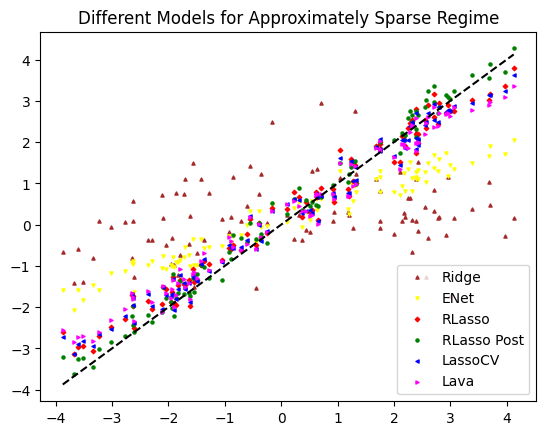

In [23]:
plt.figure()
plt.title("Different Models for Approximately Sparse Regime")
# 45 degree line
plt.plot([np.min(gXtest), np.max(gXtest)], [np.min(gXtest), np.max(gXtest)], color='black', linestyle='--')

# different models
plt.scatter(gXtest, ridge.predict(Xtest), marker='^', c='brown', s=5, label='Ridge')
plt.scatter(gXtest, enet.predict(Xtest), marker='v', c='yellow', s=5, label='ENet')
plt.scatter(gXtest, rlasso.predict(Xtest), marker='D', c='red', s=5, label='RLasso')
plt.scatter(gXtest, rlasso_post.predict(Xtest), marker='o', c='green', s=5, label='RLasso Post')
plt.scatter(gXtest, lcv.predict(Xtest), marker='<', c='blue', s=5, label='LassoCV')
plt.scatter(gXtest, lava.predict(Xtest), marker='>', c='magenta', s=5, label='Lava')
plt.legend(loc='lower right')

plt.show()

## Data Generating Process: Dense Coefficients

In [31]:
n = 100
p = 400
X, y, gX, Xtest, ytest, gXtest, Xpop, ypop, gXpop, betas = gen_data(n, p, regime="dense")

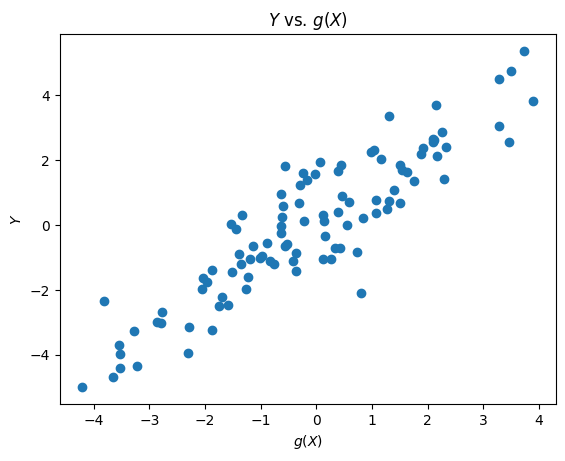

In [32]:
plt.figure()
plt.title(r"$Y$ vs. $g(X)$")
plt.scatter(gX, y)
plt.xlabel(r"$g(X)$")
plt.ylabel(r"$Y$")
plt.show()

In [33]:
print(f"theoretical R^2:, {1 - np.var(ypop - gXpop) / np.var(ypop)}")
print(f"theoretical R^2:, {np.var(gXpop) / np.var(ypop)}")

theoretical R^2:, 0.7973115024889994
theoretical R^2:, 0.7996899514700866


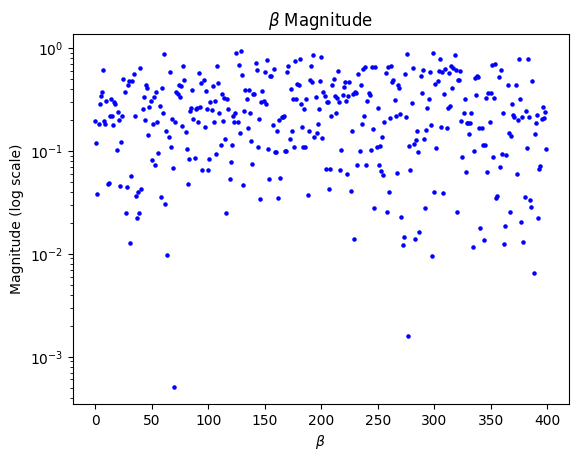

In [34]:
plt.figure()
plt.scatter(range(len(betas)), abs(betas), s=5, color='b')
plt.xlabel(r'$\beta$')
plt.ylabel('Magnitude (log scale)')
plt.title(r'$\beta$ Magnitude')
plt.yscale('log')
plt.show()

In [35]:
# Regressions
lcv = LassoCV().fit(X, y)
ridge = RidgeCV(alphas=(1, 10, 25, 50, 100)).fit(X, y)
enet = ElasticNetCV(l1_ratio=0.5).fit(X, y)
rlasso = RLasso(post=False).fit(X, y)
rlasso_post = RLasso(post=True).fit(X, y)
lava = GridSearchCV(Lava(), {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
                    scoring='r2', n_jobs=-1).fit(X, y)

In [36]:
r2_lcv = r2_score(ypop, lcv.predict(Xpop))
r2_ridge = r2_score(ypop, ridge.predict(Xpop))
r2_enet = r2_score(ypop, enet.predict(Xpop))
r2_rlasso = r2_score(ypop, rlasso.predict(Xpop))
r2_rlasso_post = r2_score(ypop, rlasso_post.predict(Xpop))
r2_lava = r2_score(ypop, lava.predict(Xpop))

In [37]:
df = pd.DataFrame({'LassoCV': [r2_lcv],
                   'RidgeCV': [r2_ridge],
                   'ElasticNetCV': [r2_enet],
                   'RLasso': [r2_rlasso],
                   'RLassoOLS': [r2_rlasso_post],
                   'Lava': [r2_lava]}).T
df.columns = ['Population R-squared']
df

,Population R-squared
LassoCV,-0.005331
RidgeCV,0.115766
ElasticNetCV,0.013437
RLasso,-0.013281
RLassoOLS,-0.000055
Lava,0.106882


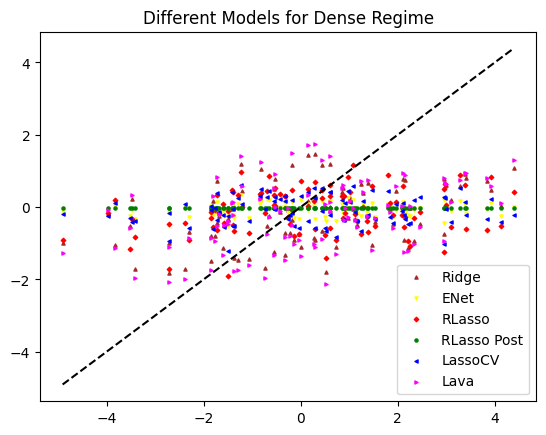

In [38]:
plt.figure()
plt.title("Different Models for Dense Regime")
# 45 degree line
plt.plot([np.min(gXtest), np.max(gXtest)], [np.min(gXtest), np.max(gXtest)], color='black', linestyle='--')

# different models
plt.scatter(gXtest, ridge.predict(Xtest), marker='^', c='brown', s=5, label='Ridge')
plt.scatter(gXtest, enet.predict(Xtest), marker='v', c='yellow', s=5, label='ENet')
plt.scatter(gXtest, rlasso.predict(Xtest), marker='D', c='red', s=5, label='RLasso')
plt.scatter(gXtest, rlasso_post.predict(Xtest), marker='o', c='green', s=5, label='RLasso Post')
plt.scatter(gXtest, lcv.predict(Xtest), marker='<', c='blue', s=5, label='LassoCV')
plt.scatter(gXtest, lava.predict(Xtest), marker='>', c='magenta', s=5, label='Lava')
plt.legend(loc='lower right')

plt.show()

## Data Generating Process: Approximately Sparse + Small Dense Part

In [39]:
n = 100
p = 400
X, y, gX, Xtest, ytest, gXtest, Xpop, ypop, gXpop, betas = gen_data(n, p, regime="sparsedense")

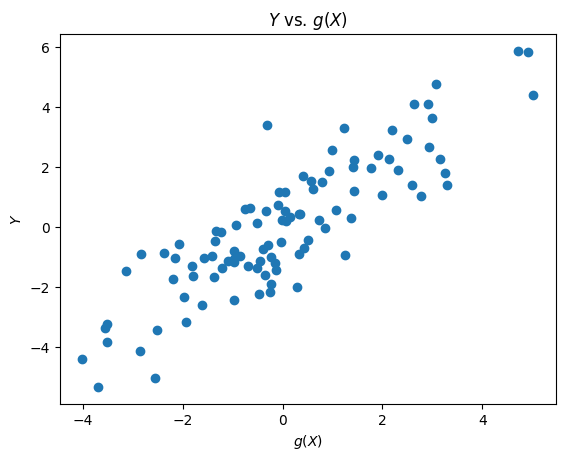

In [40]:
plt.figure()
plt.title(r"$Y$ vs. $g(X)$")
plt.scatter(gX, y)
plt.xlabel(r"$g(X)$")
plt.ylabel(r"$Y$")
plt.show()

In [41]:
print(f"theoretical R^2:, {1 - np.var(ypop - gXpop) / np.var(ypop)}")
print(f"theoretical R^2:, {np.var(gXpop) / np.var(ypop)}")

theoretical R^2:, 0.8082328510872749
theoretical R^2:, 0.8054977992522415


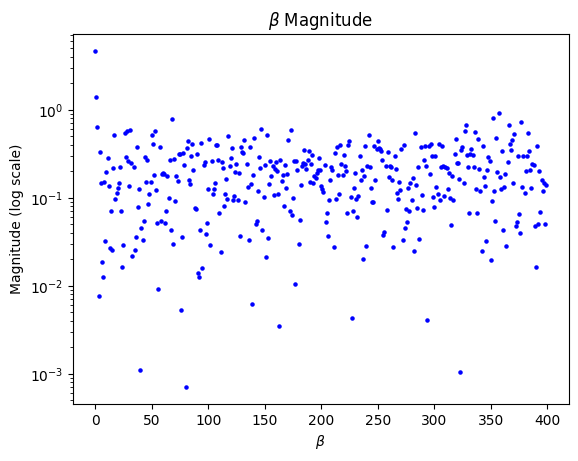

In [42]:
plt.figure()
plt.scatter(range(len(betas)), abs(betas), s=5, color='b')
plt.xlabel(r'$\beta$')
plt.ylabel('Magnitude (log scale)')
plt.title(r'$\beta$ Magnitude')
plt.yscale('log')
plt.show()

In [43]:
# Regressions
lcv = LassoCV().fit(X, y)
ridge = RidgeCV().fit(X, y)
enet = ElasticNetCV(l1_ratio=0.5).fit(X, y)
rlasso = RLasso(post=False).fit(X, y)
rlasso_post = RLasso(post=True).fit(X, y)
lava = GridSearchCV(Lava(), {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
                    scoring='r2', n_jobs=-1).fit(X, y)

In [44]:
r2_lcv = r2_score(ypop, lcv.predict(Xpop))
r2_ridge = r2_score(ypop, ridge.predict(Xpop))
r2_enet = r2_score(ypop, enet.predict(Xpop))
r2_rlasso = r2_score(ypop, rlasso.predict(Xpop))
r2_rlasso_post = r2_score(ypop, rlasso_post.predict(Xpop))
r2_lava = r2_score(ypop, lava.predict(Xpop))

In [45]:
df = pd.DataFrame({'LassoCV': [r2_lcv],
                   'RidgeCV': [r2_ridge],
                   'ElasticNetCV': [r2_enet],
                   'RLasso': [r2_rlasso],
                   'RLassoOLS': [r2_rlasso_post],
                   'Lava': [r2_lava]}).T
df.columns = ['Population R-squared']
df

,Population R-squared
LassoCV,0.262662
RidgeCV,0.128211
ElasticNetCV,0.163854
RLasso,0.251454
RLassoOLS,0.335414
Lava,0.281905


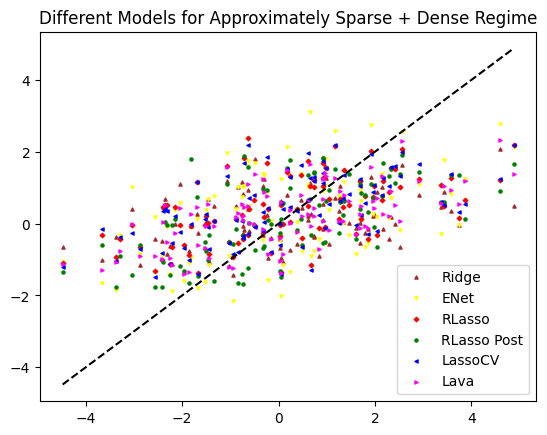

In [46]:
plt.figure()
plt.title("Different Models for Approximately Sparse + Dense Regime")
# 45 degree line
plt.plot([np.min(gXtest), np.max(gXtest)], [np.min(gXtest), np.max(gXtest)], color='black', linestyle='--')

# different models
plt.scatter(gXtest, ridge.predict(Xtest), marker='^', c='brown', s=5, label='Ridge')
plt.scatter(gXtest, enet.predict(Xtest), marker='v', c='yellow', s=5, label='ENet')
plt.scatter(gXtest, rlasso.predict(Xtest), marker='D', c='red', s=5, label='RLasso')
plt.scatter(gXtest, rlasso_post.predict(Xtest), marker='o', c='green', s=5, label='RLasso Post')
plt.scatter(gXtest, lcv.predict(Xtest), marker='<', c='blue', s=5, label='LassoCV')
plt.scatter(gXtest, lava.predict(Xtest), marker='>', c='magenta', s=5, label='Lava')
plt.legend(loc='lower right')

plt.show()